# 🩺 Churn Analysis — SQL Business Queries
**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 columns → cleaned to 26)

**Database:** SQLite (`../data/cleaned/telco_churn.db`)

**Table:** `customers`



**What this notebook does:** Answers 15 business questions using SQL,
progressing from basic GROUP BY to CTEs and window functions.
Each query is followed by a business interpretation.

**Key baseline:** Overall churn rate = 26.5% | Churned avg MRR = $74.44


## Setup

In [33]:
# ===================================================================
# SETUP — Run this cell first every time you open this notebook
# ===================================================================
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Connect to the SQLite database you created in Step 1
conn = sqlite3.connect('../data/cleaned/telco_churn.db')

# Display settings — show all columns, clean number formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Helper function — use this for EVERY query in this notebook
# It runs your SQL and returns a clean DataFrame, with a title printed above it
def run_query(sql, title=""):
    df = pd.read_sql_query(sql, conn)
    if title:
        print(f"\n{'='*60}")
        print(f"📊 {title}")
        print(f"{'='*60}")
    return df

# Verify connection works
check = run_query("SELECT COUNT(*) as total_rows FROM customers", "✅ Database Connection Check")
print(check)
print("\nSetup complete. Ready to write SQL.")



📊 ✅ Database Connection Check
   total_rows
0        7043

Setup complete. Ready to write SQL.


In [53]:
# ===================================================================
# SCHEMA VERIFICATION — confirm engineered columns exist before Q2–Q15
# ===================================================================
schema = run_query("PRAGMA table_info(customers)", "📋 Column Check")
existing_cols = schema['name'].tolist()
print(f"Total columns found: {len(existing_cols)}\n")

required_cols = ['churn_binary', 'services_count', 'tenure_band', 'has_security']
missing = [c for c in required_cols if c not in existing_cols]

if missing:
    print(f"❌ MISSING COLUMNS: {missing}")
    print("   Re-run your data cleaning notebook to add these derived columns.")
    print("   Queries 2–15 will fail without them.")
else:
    print("✅ All required engineered columns present:")
    for c in required_cols:
        print(f"   • {c}")
    print("\nReady to run all 15 queries.")


📊 📋 Column Check
Total columns found: 26

✅ All required engineered columns present:
   • churn_binary
   • services_count
   • tenure_band
   • has_security

Ready to run all 15 queries.


## Query 1 — Overall Churn Rate
**Business Question:** What is our baseline churn rate, and how much revenue is affected?

**SQL Concepts used:** COUNT, GROUP BY, subquery for percentage, SUM, AVG, ROUND


In [34]:
q1 = run_query("""
    SELECT
        Churn,
        COUNT(*) AS customer_count,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM customers), 1) AS pct_of_total,
        ROUND(SUM(MonthlyCharges), 2) AS total_monthly_revenue,
        ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
        ROUND(SUM(MonthlyCharges) * 12, 2) AS annualized_revenue
    FROM customers
    GROUP BY Churn
    ORDER BY Churn DESC
""", "Q1: Overall Churn Rate & Revenue Impact")
q1



📊 Q1: Overall Churn Rate & Revenue Impact


,Churn,customer_count,pct_of_total,total_monthly_revenue,avg_monthly_charges,annualized_revenue
0,Yes,1869,26.50,"139,130.85",74.44,"1,669,570.20"
1,No,5174,73.50,"316,985.75",61.27,"3,803,829.00"


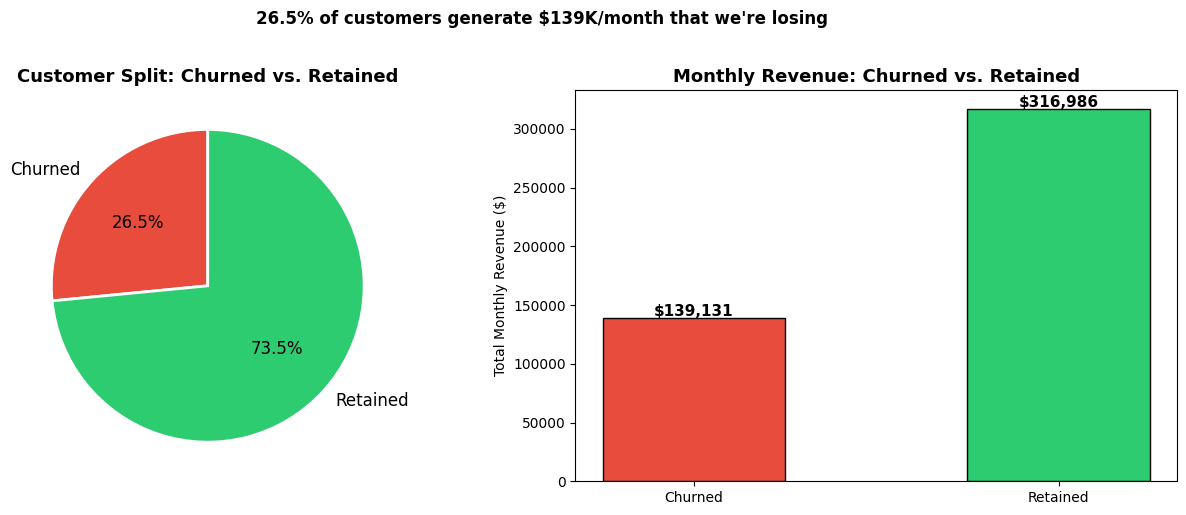

✅ Chart saved to docs/q1_overall_churn.png


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels   = ['Churned', 'Retained']
counts   = q1['customer_count'].values
revenues = q1['total_monthly_revenue'].values
colors   = ['#e74c3c', '#2ecc71']

# Chart 1: Customer count split (Pie)
axes[0].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[0].set_title('Customer Split: Churned vs. Retained',
                  fontsize=13, fontweight='bold')

# Chart 2: Monthly revenue by churn status (Bar)
bars = axes[1].bar(labels, revenues, color=colors, edgecolor='black', width=0.5)
axes[1].set_title('Monthly Revenue: Churned vs. Retained',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Monthly Revenue ($)')
for bar, val in zip(bars, revenues):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1500,
                 f'${val:,.0f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle("26.5% of customers generate $139K/month that we're losing",
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/q1_overall_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to docs/q1_overall_churn.png")

### 📌 Business Insight — Q1

Our churn rate is **26.5%** — 1 in 4 customers is leaving.

Churned customers paid an avg of **`$74.44/month`**, which is **`$13.17 more`**  
than retained customers ($61.27/month). We are disproportionately losing  
our higher-paying customers.

The `~$139,130` in monthly revenue from churned customers = **`~$1.67M annually lost`**.

This is the business problem we are solving. Every subsequent query tells us  
WHERE this is happening, WHO it's happening to, and WHAT to do about it.

## Query 2 — Churn Rate by Contract Type
**Business Question:** Does commitment level predict churn? By how much does
contract type change the probability of a customer leaving?

**SQL Concepts:** GROUP BY, CASE WHEN for conditional SUM, percentage calculation

**Why it matters:** This is the #1 actionable finding — if we can move customers
from month-to-month to annual, we dramatically reduce churn.


In [35]:
q2 = run_query("""
    SELECT
        Contract,
        COUNT(*) AS total_customers,
        SUM(churn_binary) AS churned_customers,
        COUNT(*) - SUM(churn_binary) AS retained_customers,
        ROUND(SUM(churn_binary) * 100.0 / COUNT(*), 1) AS churn_rate_pct,
        ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
        ROUND(SUM(CASE WHEN Churn = 'Yes' THEN MonthlyCharges ELSE 0 END), 2)
            AS monthly_revenue_lost,
        ROUND(SUM(CASE WHEN Churn = 'Yes' THEN MonthlyCharges ELSE 0 END) * 12, 2)
            AS annual_revenue_lost
    FROM customers
    GROUP BY Contract
    ORDER BY churn_rate_pct DESC
""", "Q2: Churn Rate by Contract Type")
q2



📊 Q2: Churn Rate by Contract Type


,Contract,total_customers,churned_customers,retained_customers,churn_rate_pct,avg_monthly_charges,monthly_revenue_lost,annual_revenue_lost
0,Month-to-month,3875,1655,2220,42.70,66.40,"120,847.10","1,450,165.20"
1,One year,1473,166,1307,11.30,65.05,"14,118.45","169,421.40"
2,Two year,1695,48,1647,2.80,60.77,"4,165.30","49,983.60"


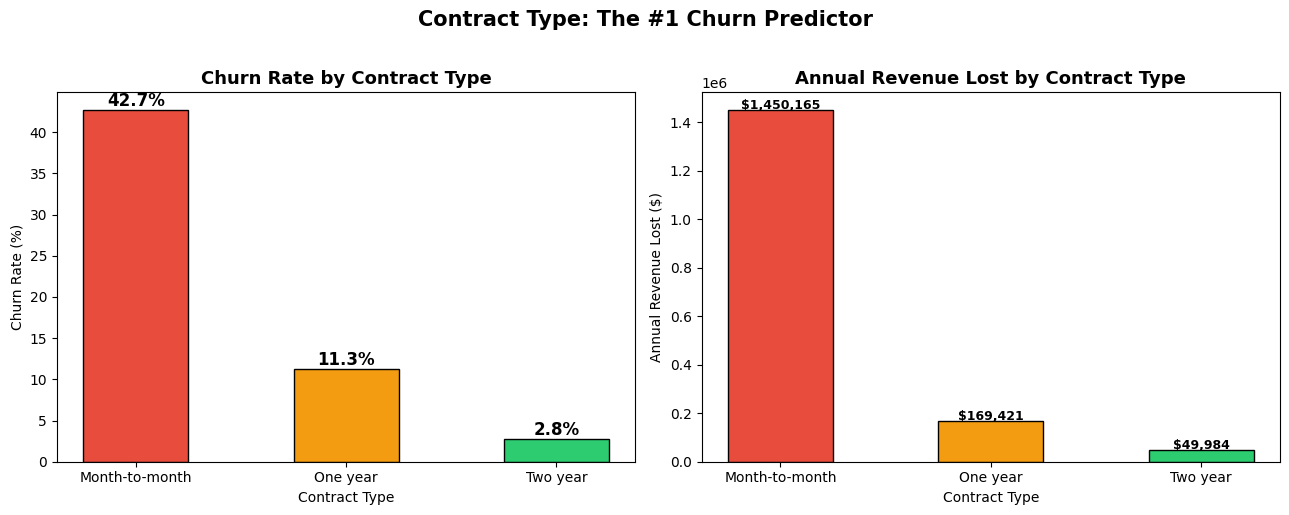

✅ Chart saved to docs/q2_contract_churn.png


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

contracts = q2['Contract']
churn_rates = q2['churn_rate_pct']
colors = ['#e74c3c', '#f39c12', '#2ecc71']  # Red → Yellow → Green

# Chart 1: Churn Rate
axes[0].bar(contracts, churn_rates, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Contract Type')
for i, v in enumerate(churn_rates):
    axes[0].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold', fontsize=12)

# Chart 2: Annual Revenue Lost
rev = q2['annual_revenue_lost']
axes[1].bar(contracts, rev, color=colors, edgecolor='black', width=0.5)
axes[1].set_title('Annual Revenue Lost by Contract Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Annual Revenue Lost ($)')
axes[1].set_xlabel('Contract Type')
for i, v in enumerate(rev):
    axes[1].text(i, v + 2000, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Contract Type: The #1 Churn Predictor', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/q2_contract_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to docs/q2_contract_churn.png")


### 📌 Business Insight — Q2
Month-to-month churn: **42.7%**
One-year churn: **11.3%**
Two-year churn: **2.8%**

Month-to-month customers churn at 15.25 × the rate of two-year customers.
This is a powerful finding in the dataset.

`~$1.45 million` in annual revenue is lost from M2M customers alone.

**Recommendation:** Create a time-limited incentive to convert M2M to annual:
- Offer 10–15% annual discount
- Unlock a premium feature for annual subscribers
- Even converting 10% of M2M customers to annual would protect `~$145k`


## Query 3 — Churn Rate by Internet Service (Plan Tier Proxy)
**Business Question:** Does service tier predict churn?
Are high-paying premium customers more at risk?

**SQL Concepts:** GROUP BY, multiple metrics per group, ORDER BY


In [37]:
q3 = run_query("""
    SELECT
        InternetService,
        COUNT(*) AS total_customers,
        SUM(churn_binary) AS churned,
        ROUND(SUM(churn_binary) * 100.0 / COUNT(*), 1) AS churn_rate_pct,
        ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
        ROUND(AVG(tenure), 1) AS avg_tenure_months,
        ROUND(AVG(services_count), 1) AS avg_services_used,
        ROUND(SUM(CASE WHEN Churn='Yes' THEN MonthlyCharges ELSE 0 END)*12, 2)
            AS annual_rev_lost
    FROM customers
    GROUP BY InternetService
    ORDER BY churn_rate_pct DESC
""", "Q3: Churn Rate by Internet Service (Plan Tier Proxy)")
q3



📊 Q3: Churn Rate by Internet Service (Plan Tier Proxy)


,InternetService,total_customers,churned,churn_rate_pct,avg_monthly,avg_tenure_months,avg_services_used,annual_rev_lost
0,Fiber optic,3096,1297,41.90,91.50,32.90,4.20,"1,371,600.60"
1,DSL,2421,459,19.00,58.10,32.80,3.70,"270,350.40"
2,No,1526,113,7.40,21.08,30.50,1.20,"27,619.20"


### 📌 Business Insight — Q3
Fiber optic (premium tier): **41.9%** churn — paying avg `$91.50/month`
DSL (basic tier): **19.0%** churn
No internet: **7.4%** churn

**This is counterintuitive and critical:** Our highest-paying customers
(Fiber optic, avg `~$90/month`) churn the MOST. In SaaS, this is equivalent
to your Enterprise plan customers churning while SMB customers stay.

Possible reasons:
1. Unmet expectations — premium customers expect premium reliability
2. Competitive alternatives — fiber has more substitute providers
3. High price sensitivity without strong stickiness features

**Recommendation:** We can launch a "Fiber Customer Success" program targeting
Fiber + Month-to-month customers in their first 12 months specifically.


## Query 4 — Tenure Comparison: Churned vs. Retained
**Business Question:** At what point in the customer lifecycle is churn happening?
When do we need to intervene?

**SQL Concepts:** GROUP BY Churn, AVG, MIN, MAX across groups


In [38]:
q4 = run_query("""
    SELECT
        Churn,
        COUNT(*) AS customer_count,
        ROUND(AVG(tenure), 1) AS avg_tenure_months,
        MIN(tenure) AS min_tenure,
        MAX(tenure) AS max_tenure,
        ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges,
        ROUND(AVG(TotalCharges), 2) AS avg_lifetime_value_proxy
    FROM customers
    GROUP BY Churn
""", "Q4: Tenure Profile — Churned vs. Retained")
q4



📊 Q4: Tenure Profile — Churned vs. Retained


,Churn,customer_count,avg_tenure_months,min_tenure,max_tenure,avg_monthly_charges,avg_lifetime_value_proxy
0,No,5174,37.60,0,72,61.27,"2,549.91"
1,Yes,1869,18.00,1,72,74.44,"1,531.80"


### 📌 Business Insight — Q4
Churned customers stayed an average of **18 months**.
Retained customers averaged **37.6 months** — 2 × longer.

This confirms: churn is primarily an EARLY lifecycle problem.
Most customers who leave do so before they've built switching costs
or truly experienced the value of the product.

**In SaaS terms:** This is a Time-to-Value (TTV) problem.
Customers are leaving before they reach their "Aha! moment."

**Intervention focus:** The first 12–18 months are the highest ROI
window for retention investment. After ~24 months, customers rarely leave.


## Query 5 — Churn Rate by Tenure Band (Lifecycle Stage)
**Business Question:** At which lifecycle stage is churn highest?
Where exactly should we focus onboarding/retention efforts?

**SQL Concepts:** GROUP BY on derived column (tenure_band), custom ORDER BY with CASE WHEN


In [39]:
q5 = run_query("""
    SELECT
        tenure_band,
        COUNT(*) AS total_customers,
        SUM(churn_binary) AS churned,
        COUNT(*) - SUM(churn_binary) AS retained,
        ROUND(SUM(churn_binary) * 100.0 / COUNT(*), 1) AS churn_rate_pct,
        ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
        ROUND(SUM(CASE WHEN Churn='Yes' THEN MonthlyCharges ELSE 0 END) * 12, 2)
            AS annual_rev_lost
    FROM customers
    GROUP BY tenure_band
    ORDER BY
        CASE tenure_band
            WHEN '0-12 months'  THEN 1
            WHEN '13-24 months' THEN 2
            WHEN '25-36 months' THEN 3
            WHEN '37-48 months' THEN 4
            WHEN '49-60 months' THEN 5
            WHEN '61-72 months' THEN 6
        END
""", "Q5: Churn Rate by Tenure Band (Lifecycle Stage)")
q5



📊 Q5: Churn Rate by Tenure Band (Lifecycle Stage)


,tenure_band,total_customers,churned,retained,churn_rate_pct,avg_monthly,annual_rev_lost
0,0-12 months,2186,1037,1149,47.40,56.10,"827,451.00"
1,13-24 months,1024,294,730,28.70,61.36,"276,979.80"
2,25-36 months,832,180,652,21.60,65.58,"182,015.40"
3,37-48 months,762,145,617,19.00,66.32,"147,534.60"
4,49-60 months,832,120,712,14.40,70.55,"126,982.80"
5,61-72 months,1407,93,1314,6.60,75.95,"108,606.60"


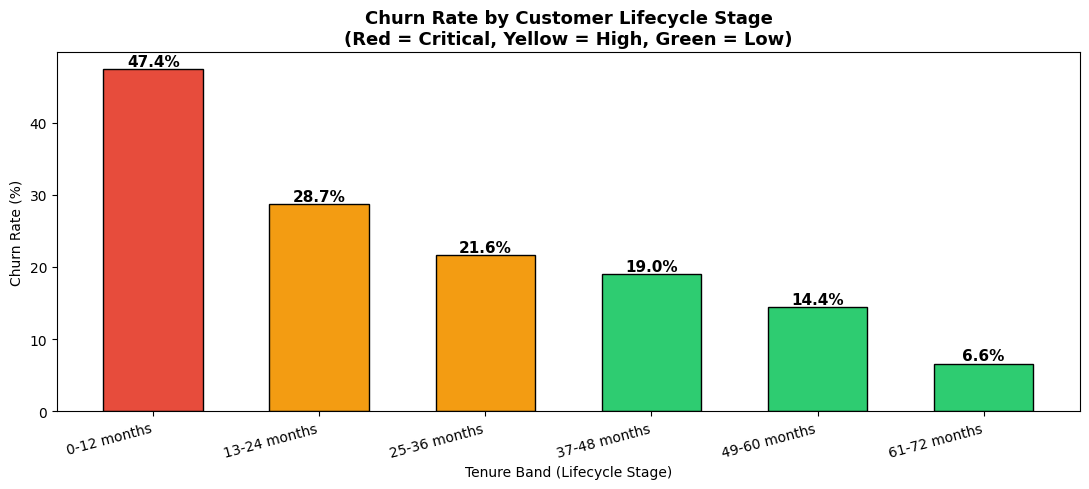

✅ Chart saved to docs/q5_tenure_band_churn.png


In [40]:
fig, ax = plt.subplots(figsize=(11, 5))

colors_by_churn = ['#e74c3c' if r > 35 else '#f39c12' if r > 20 else '#2ecc71'
                   for r in q5['churn_rate_pct']]

bars = ax.bar(q5['tenure_band'], q5['churn_rate_pct'],
              color=colors_by_churn, edgecolor='black', width=0.6)

ax.set_title('Churn Rate by Customer Lifecycle Stage\n(Red = Critical, Yellow = High, Green = Low)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure Band (Lifecycle Stage)')
ax.set_ylabel('Churn Rate (%)')
ax.set_xticks(range(len(q5['tenure_band'])))
ax.set_xticklabels(q5['tenure_band'], rotation=15, ha='right')

for i, (bar, val) in enumerate(zip(bars, q5['churn_rate_pct'])):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f'{val}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('../docs/q5_tenure_band_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to docs/q5_tenure_band_churn.png")


### 📌 Business Insight — Q5
0-12 months: **47.4%** churn ← highest stage
13-24 months: **28.7%** churn
25-36 months: **21.6%** churn
37+ months: **19.0%** or less ← stabilizes here

**The "leaky bucket" is concentrated in Year 1.**
After month 24, churn drops dramatically and stays low.

**Implication:** Getting a customer to their 25th month is the most important
retention milestone. An onboarding program that actively nurtures customers
through the first 24 months is the single highest-ROI retention investment.

Annual revenue lost from just the 0-12 month band: **$827,451.00**


## Query 6 — Revenue at Risk (High-Risk Retained Customers)
**Business Question:** How much of our CURRENT revenue sits with customers
who match the exact profile of churners? How much could we lose next month?

**New SQL Concept:** CTE (Common Table Expression) — WITH name AS (...)

**Why it matters:** This is forward-looking analysis — it lets us act BEFORE
customers leave, not after.


In [41]:
q6 = run_query("""
    WITH high_risk_retained AS (
        -- Step 1: Find retained customers who look like churners
        -- Profile: month-to-month + no security/support + early tenure
        -- These are the three strongest churn predictors from Q2, Q3, Q5
        SELECT
            customerID,
            MonthlyCharges,
            tenure,
            Contract,
            has_security,
            tenure_band,
            InternetService
        FROM customers
        WHERE
            Churn = 'No'                         -- Still with us (retained)
            AND Contract = 'Month-to-month'      -- No commitment
            AND has_security = 'No'              -- No protection services
            AND tenure <= 24                     -- Early lifecycle stage
    )
    -- Step 2: Calculate revenue summary from that high-risk group
    SELECT
        COUNT(*) AS high_risk_customers,
        ROUND(SUM(MonthlyCharges), 2) AS monthly_revenue_at_risk,
        ROUND(SUM(MonthlyCharges) * 12, 2) AS annual_revenue_at_risk,
        ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_per_customer,
        ROUND(AVG(tenure), 1) AS avg_tenure_months
    FROM high_risk_retained
""", "Q6: Revenue At Risk — High-Risk Retained Customers")
q6



📊 Q6: Revenue At Risk — High-Risk Retained Customers


,high_risk_customers,monthly_revenue_at_risk,annual_revenue_at_risk,avg_monthly_per_customer,avg_tenure_months
0,1008,"49,037.75","588,453.00",48.65,8.60


### 📌 Business Insight — Q6
There are **1008 retained customers** who match the high-risk churn profile
(month-to-month + no security + ≤24 months tenure).

They represent **`$49,037/month`** in current revenue = **`$588,453/year`** at risk.

If we apply the historical churn rate for this profile (~45% from Q2 analysis),
we would expect to lose ~**`$264,804`** annually from this group alone.

**Business Case for Action:**
A targeted retention program for this group (free 60-day security trial + annual
contract incentive) costing `$30` per customer × 1008 customers = `$30,240` investment
could protect `$264,804` in revenue.

ROI = `$264,804 / $30,240 = 8.8×`

## Query 7 — Service Adoption Depth vs. Churn Rate
**Business Question:** Does using more services/features reduce churn?
Is feature adoption a retention strategy?

**SQL Concepts:** GROUP BY on services_count (numeric derived column), multiple metrics

**Why it matters:** Proves the business case for cross-selling and
deeper product engagement as retention tools (not just revenue tools).


In [42]:
q7 = run_query("""
    SELECT
        services_count,
        COUNT(*) AS total_customers,
        SUM(churn_binary) AS churned,
        ROUND(SUM(churn_binary) * 100.0 / COUNT(*), 1) AS churn_rate_pct,
        ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
        ROUND(AVG(tenure), 1) AS avg_tenure_months
    FROM customers
    GROUP BY services_count
    ORDER BY services_count ASC
""", "Q7: Service Adoption Depth vs. Churn Rate")
q7



📊 Q7: Service Adoption Depth vs. Churn Rate


,services_count,total_customers,churned,churn_rate_pct,avg_monthly,avg_tenure_months
0,0,80,35,43.80,24.90,8.90
1,1,1701,359,21.10,30.08,20.90
2,2,1188,390,32.80,51.13,24.30
3,3,965,352,36.50,69.36,24.50
4,4,922,289,31.30,78.73,32.10
5,5,908,232,25.60,86.31,41.50
6,6,676,152,22.50,93.64,51.10
7,7,395,49,12.40,99.43,59.80
8,8,208,11,5.30,104.63,66.30


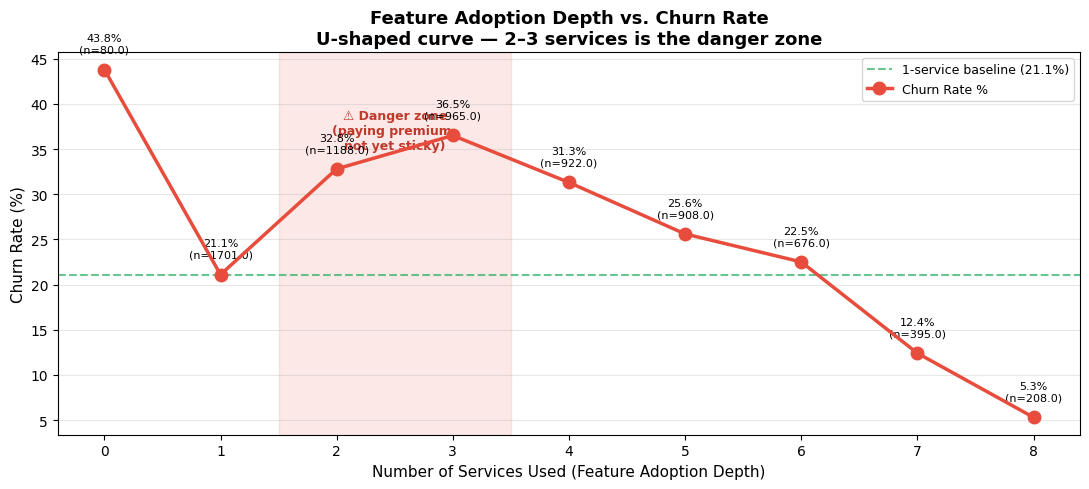

✅ Chart saved to docs/q7_service_adoption_churn.png


In [43]:
fig, ax = plt.subplots(figsize=(11, 5))

# Shade the 2–3 service danger zone
ax.axvspan(1.5, 3.5, alpha=0.12, color='#e74c3c')
ax.annotate('⚠ Danger zone\n(paying premium,\nnot yet sticky)',
            xy=(2.5, 35), ha='center', fontsize=9,
            color='#c0392b', fontweight='bold')

# Reference line at Tier 1 (1-service) churn rate
ax.axhline(y=21.1, color='#27ae60', linestyle='--',
           linewidth=1.5, alpha=0.7, label='1-service baseline (21.1%)')

ax.plot(q7['services_count'], q7['churn_rate_pct'],
        marker='o', color='#e74c3c', linewidth=2.5,
        markersize=9, label='Churn Rate %', zorder=5)

ax.set_title('Feature Adoption Depth vs. Churn Rate\n'
             'U-shaped curve — 2–3 services is the danger zone',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Services Used (Feature Adoption Depth)', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_xticks(q7['services_count'])
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=9)

for _, row in q7.iterrows():
    ax.annotate(f"{row['churn_rate_pct']}%\n(n={row['total_customers']})",
                xy=(row['services_count'], row['churn_rate_pct']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../docs/q7_service_adoption_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to docs/q7_service_adoption_churn.png")

### 📌 Business Insight — Q7
Service adoption does NOT linearly reduce churn — it creates a U-shaped curve:
- 0 services: 43.8% churn (phone-only customers — no internet stickiness)
- 1 service: 21.1% churn ← BEST single-service retention
- 2-3 services: 33-37% churn ← DANGER ZONE — churn spikes back up
- 4-5 services: 25-32% churn (declining again)
- 6+ services: 12-23% churn (strong protection zone)
- 8 services: 5.3% churn (near-zero churn — fully embedded)
WHY THE SPIKE AT 2-3 SERVICES?
Customers who added 1-2 internet add-ons are paying significantly more
($51-$69/month vs $30 for single service) but haven't built enough
product dependency to feel locked in. They're paying premium prices
with maximum exit flexibility — a dangerous combination.

REVISED RECOMMENDATION:
The activation threshold is NOT 3 services — it's 6+.
Customers in the 2-3 service band are in a high-churn danger zone.
CS should actively push these customers toward service 4 and beyond.
Define onboarding success as: "6 services active within 90 days."


## Query 8 — Payment Method vs. Churn Rate
**Business Question:** Does payment method (auto-pay vs. manual) predict churn?
Can we reduce churn just by changing how customers pay?

**SQL Concepts:** GROUP BY PaymentMethod, multiple metrics

**Why it matters:** This is a behavioural insight — auto-pay creates friction
to cancel, which passively reduces churn.


In [44]:
q8 = run_query("""
    SELECT
        PaymentMethod,
        COUNT(*) AS total_customers,
        SUM(churn_binary) AS churned,
        ROUND(SUM(churn_binary) * 100.0 / COUNT(*), 1) AS churn_rate_pct,
        ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
        ROUND(AVG(tenure), 1) AS avg_tenure_months,
        ROUND(SUM(CASE WHEN Churn='Yes' THEN MonthlyCharges ELSE 0 END) * 12, 2)
            AS annual_rev_lost
    FROM customers
    GROUP BY PaymentMethod
    ORDER BY churn_rate_pct DESC
""", "Q8: Payment Method vs. Churn Rate")
q8



📊 Q8: Payment Method vs. Churn Rate


,PaymentMethod,total_customers,churned,churn_rate_pct,avg_monthly,avg_tenure_months,annual_rev_lost
0,Electronic check,2365,1071,45.30,76.26,25.20,"1,011,465.00"
1,Mailed check,1612,308,19.10,43.92,21.80,"201,643.20"
2,Bank transfer (automatic),1544,258,16.70,67.19,43.70,"241,102.80"
3,Credit card (automatic),1522,232,15.20,66.51,43.30,"215,359.20"


### 📌 Business Insight — Q8
- Electronic check: **45.3%** churn — the highest
- Mailed check: **19.1%** (surprisingly lower than electronic)
- Auto-pay (bank transfer + credit card): avg **~16%** churn
- Electronic check payers churn at **~2.8×** the rate of auto-pay customers.

Note: Mailed check actually churns LOWER than electronic check — the opposite
of what you'd expect. Why? Mailed check customers tend to be older, less
internet-savvy (more like the two-year contract type mentally).
Electronic check is the worst — it's digital enough to set up but not
automated, so customers see every charge actively.

**Low-cost, high-ROI recommendation:**
Incentivize switching to auto-pay:
- "`$2–3`/month discount for auto-pay enrollment"
- "One free month with auto-pay signup"


Electronic check customers currently generate **$1,011,465 in annual churned revenue**.
If auto-pay enrollment drops their churn rate from 45.3% → ~16%,
that is a **64.7% reduction** in churn for this group
(calculated as: (45.3% − 16%) / 45.3% = 64.7%).

Projected saving: `$1,011,465 × 64.7%` ≈ **`$654K/year`** in recovered revenue.


## Query 9 — Senior Citizen Churn Patterns
**Business Question:** Do senior citizens churn more, and is TechSupport
adoption the key differentiator?

**SQL Concepts:** GROUP BY, CASE WHEN for conditional count, CAST for type conversion

**Why it matters:** Finding a specific at-risk persona (seniors without tech support)
allows the CS team to proactively target them before they churn.


In [45]:
q9 = run_query("""
    SELECT
        SeniorCitizen,
        COUNT(*) AS total_customers,
        SUM(churn_binary) AS churned,
        ROUND(SUM(churn_binary) * 100.0 / COUNT(*), 1) AS churn_rate_pct,
        ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
        ROUND(AVG(tenure), 1) AS avg_tenure_months,
        ROUND(AVG(CAST(services_count AS FLOAT)), 1) AS avg_services_used,
        SUM(CASE WHEN TechSupport = 'Yes' THEN 1 ELSE 0 END) AS count_with_tech_support,
        ROUND(
            SUM(CASE WHEN TechSupport = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1
        ) AS pct_with_tech_support
    FROM customers
    GROUP BY SeniorCitizen
    ORDER BY SeniorCitizen
""", "Q9: Senior Citizen Segment — Churn & Support Patterns")
q9



📊 Q9: Senior Citizen Segment — Churn & Support Patterns


,SeniorCitizen,total_customers,churned,churn_rate_pct,avg_monthly,avg_tenure_months,avg_services_used,count_with_tech_support,pct_with_tech_support
0,No,5901,1393,23.60,61.85,32.20,3.30,1784,30.20
1,Yes,1142,476,41.70,79.82,33.30,3.80,260,22.80


In [46]:
q9b = run_query("""
    SELECT
        SeniorCitizen,
        TechSupport,
        COUNT(*) AS customers,
        SUM(churn_binary) AS churned,
        ROUND(SUM(churn_binary) * 100.0 / COUNT(*), 1) AS churn_rate_pct
    FROM customers
    WHERE TechSupport != 'No internet service'
    GROUP BY SeniorCitizen, TechSupport
    ORDER BY SeniorCitizen, churn_rate_pct DESC
""", "Q9b: Senior Citizen × TechSupport Cross-Tab")
q9b



📊 Q9b: Senior Citizen × TechSupport Cross-Tab


,SeniorCitizen,TechSupport,customers,churned,churn_rate_pct
0,No,No,2643,1026,38.80
1,No,Yes,1784,259,14.50
2,Yes,No,830,420,50.60
3,Yes,Yes,260,51,19.60


### 📌 Business Insight — Q9 + Q9b
Senior citizens churn at **41.7%** vs non-seniors at **23.6%**.
Seniors churn at 1.77× the rate of non-seniors.
Among seniors WITHOUT TechSupport: **50.6%** churn
Among seniors WITH TechSupport: **19.6%** churn
THIS IS THE SMOKING GUN:
TechSupport reduces senior churn by **31 percentage points** (50.6% → 19.6%).
With TechSupport, seniors churn at nearly the SAME rate as non-seniors (19.6% vs 23.6%).

**Causal finding:** Seniors don't inherently churn more — they churn more
because they lack TechSupport. Fix the support gap, fix the churn gap.

**Specific recommendation:**
Automatically include a 60-day free TechSupport trial for all senior customers at signup.
The math: 260 seniors HAVE TechSupport at 19.6% vs 830 without at 50.6%.
If we gave all 830 seniors-without-support a free trial and retained even 50% at
the 19.6% rate → `~128` fewer churners × avg `$79.82`/month × 12 = **`~$122K`/year saved**.


## Query 10 — High-Value Churner Profiles
**Business Question:** Which churned customers were our biggest revenue losses?
What profile did they share? Are they win-back candidates?
**New SQL Concept:** Subquery — a query nested inside another query
The inner query calculates a value; the outer query uses it to filter.


In [47]:
q10 = run_query("""
    SELECT
        Contract,
        tenure_band,
        InternetService,
        has_security,
        COUNT(*) AS high_value_churners,
        ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
        ROUND(SUM(MonthlyCharges), 2) AS total_monthly_lost,
        ROUND(SUM(MonthlyCharges) * 12, 2) AS annual_revenue_lost,
        ROUND(AVG(tenure), 1) AS avg_tenure,
        ROUND(AVG(TotalCharges), 2) AS avg_lifetime_value
    FROM customers
    WHERE
        Churn = 'Yes'
        AND MonthlyCharges > (
            SELECT AVG(MonthlyCharges) FROM customers WHERE Churn = 'Yes'
        )
    GROUP BY Contract, tenure_band, InternetService, has_security
    HAVING COUNT(*) >= 10
    ORDER BY avg_monthly DESC
    LIMIT 15
""", "Q10: High-Value Churner Profiles (Above Average Revenue)")
q10



📊 Q10: High-Value Churner Profiles (Above Average Revenue)


,Contract,tenure_band,InternetService,has_security,high_value_churners,avg_monthly,total_monthly_lost,annual_revenue_lost,avg_tenure,avg_lifetime_value
0,Two year,61-72 months,Fiber optic,Yes,16,107.42,"1,718.75","20,625.00",67.10,"7,167.60"
1,One year,61-72 months,Fiber optic,Yes,22,106.40,"2,340.75","28,089.00",67.40,"7,207.44"
2,One year,49-60 months,Fiber optic,Yes,20,106.09,"2,121.75","25,461.00",54.70,"5,852.98"
3,One year,37-48 months,Fiber optic,Yes,14,103.51,"1,449.15","17,389.80",42.30,"4,389.56"
4,One year,61-72 months,Fiber optic,No,12,99.64,"1,195.70","14,348.40",64.20,"6,402.73"
5,Month-to-month,61-72 months,Fiber optic,No,17,98.91,"1,681.45","20,177.40",66.00,"6,586.62"
6,Month-to-month,49-60 months,Fiber optic,Yes,15,97.77,"1,466.60","17,599.20",53.90,"5,261.88"
7,One year,49-60 months,Fiber optic,No,13,97.54,"1,268.00","15,216.00",56.00,"5,419.45"
8,Month-to-month,37-48 months,Fiber optic,Yes,34,97.17,"3,303.85","39,646.20",42.40,"4,099.00"
9,Month-to-month,13-24 months,Fiber optic,Yes,58,94.67,"5,490.80","65,889.60",17.90,"1,686.61"


### 📌 Business Insight — Q10
High-value churners (above the avg churned rate of $74.44/month):

Rank 1: Two year + 61-72 months + Fiber optic + Security
→ 16 customers, avg `$107.42`/month, `$20,625` annual revenue lost
These are the most committed customers we ever had — 5+ year tenure,
premium plan, security-protected, on a 2-year contract.
Something went deeply wrong for them to leave.

All 15 top profiles = Fiber optic customers.
This is a Fiber service satisfaction problem, not just a price problem.

"Frustrated Loyalists" (37+ months tenure in this list):
- They proved loyalty for 3-6 years
- They left for a SPECIFIC reason — a bad interaction, price hike, or competitive offer
- They are the best win-back candidates because they already proved willingness to stay

Win-back ROI: Recovering just 10% of top 5 groups:
(16 + 22 + 20 + 14 + 12) × 10% = 8 customers × `$107`/month × 12 = `$10,272`/year
from a few personal phone calls. Assign senior CS reps — this is worth their time.

## Query 11 — Bundle Tiers vs. Churn Rate
**Business Question:** What is the "magic number" of services for retention?
Where is the activation threshold?
**SQL Concept:** CASE WHEN in SELECT to create a computed grouping column


In [48]:
q11 = run_query("""
    SELECT
        CASE
            WHEN services_count = 0           THEN 'Tier 0: No add-ons'
            WHEN services_count BETWEEN 1 AND 2 THEN 'Tier 1: Light (1-2)'
            WHEN services_count BETWEEN 3 AND 5 THEN 'Tier 2: Moderate (3-5)'
            WHEN services_count >= 6          THEN 'Tier 3: Power User (6+)'
        END AS bundle_tier,
        COUNT(*) AS total_customers,
        SUM(churn_binary) AS churned,
        ROUND(SUM(churn_binary) * 100.0 / COUNT(*), 1) AS churn_rate_pct,
        ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
        ROUND(AVG(tenure), 1) AS avg_tenure_months,
        ROUND(AVG(TotalCharges), 2) AS avg_lifetime_value
    FROM customers
    GROUP BY bundle_tier
    ORDER BY churn_rate_pct DESC
""", "Q11: Bundle Tier vs. Churn Rate")
q11



📊 Q11: Bundle Tier vs. Churn Rate


,bundle_tier,total_customers,churned,churn_rate_pct,avg_monthly,avg_tenure_months,avg_lifetime_value
0,Tier 0: No add-ons,80,35,43.80,24.90,8.90,221.99
1,Tier 2: Moderate (3-5),2795,873,31.20,77.95,32.50,"2,513.64"
2,Tier 1: Light (1-2),2889,749,25.90,38.73,22.30,693.49
3,Tier 3: Power User (6+),1279,212,16.60,97.22,56.20,"5,480.31"


### 📌 Business Insight — Q11
Tier 0 (no add-ons): 43.8% churn
Tier 2 (3-5 services): 31.2% churn ← HIGHER than Tier 1!
Tier 1 (1-2 services): 25.9% churn
Tier 3 (6+ services): 16.6% churn

COUNTERINTUITIVE FINDING: Moderate users (3-5 services, Tier 2) churn MORE
than light users (1-2 services, Tier 1). This confirms the Q7 danger zone.

Tier 2 customers pay `$77.95`/month avg — significantly more than Tier 1's `$38.73`.
They're paying premium prices but have not yet reached full ecosystem embeddedness.

The REAL activation threshold is Tier 3 (6+ services), not Tier 2.

Revised recommendation:
- Stop measuring success at "3 services" — that's the danger zone
- Design all cross-sell flows to target 6+ services (Tier 3)
- Customers stuck in Tier 2 need active CS outreach to push them further
- Add in-app prompt: "You're using 4 services — customers using 6+ stay 2× longer"


## Query 12 — Top 10 Highest-Churn Customer Profiles
**Business Question:** What specific combinations of factors predict churn most reliably?
Give CS a precise targeting list — not "all at-risk customers" but exact profiles.
**SQL Concepts:** CTE (WITH), HAVING to filter small groups, LIMIT for top-N ranking


In [49]:
q12 = run_query("""
    WITH churn_profiles AS (
        SELECT
            Contract,
            InternetService,
            has_security,
            tenure_band,
            COUNT(*) AS total_in_profile,
            SUM(churn_binary) AS churned_in_profile,
            ROUND(SUM(churn_binary) * 100.0 / COUNT(*), 1) AS churn_rate_pct,
            ROUND(AVG(MonthlyCharges), 2) AS avg_monthly,
            ROUND(SUM(MonthlyCharges * churn_binary) * 12, 2) AS annual_rev_at_risk
        FROM customers
        GROUP BY Contract, InternetService, has_security, tenure_band
        HAVING COUNT(*) >= 25
    )
    SELECT
        Contract,
        InternetService,
        has_security AS has_security_support,
        tenure_band,
        total_in_profile AS customers_in_group,
        churned_in_profile AS churned,
        churn_rate_pct,
        avg_monthly,
        annual_rev_at_risk
    FROM churn_profiles
    ORDER BY churn_rate_pct DESC
    LIMIT 10
""", "Q12: Top 10 Highest-Churn Customer Profiles")
q12



📊 Q12: Top 10 Highest-Churn Customer Profiles


,Contract,InternetService,has_security_support,tenure_band,customers_in_group,churned,churn_rate_pct,avg_monthly,annual_rev_at_risk
0,Month-to-month,Fiber optic,No,0-12 months,764,557,72.90,80.92,"545,832.00"
1,Month-to-month,Fiber optic,Yes,0-12 months,152,86,56.60,87.89,"92,307.60"
2,Month-to-month,Fiber optic,No,13-24 months,293,156,53.20,85.62,"161,794.80"
3,Month-to-month,Fiber optic,No,25-36 months,203,103,50.70,88.09,"109,840.20"
4,Month-to-month,DSL,No,0-12 months,424,209,49.30,44.61,"107,726.40"
5,Month-to-month,Fiber optic,Yes,13-24 months,132,59,44.70,91.80,"66,768.00"
6,Month-to-month,Fiber optic,No,49-60 months,92,40,43.50,90.75,"44,683.80"
7,Month-to-month,Fiber optic,No,37-48 months,124,52,41.90,91.03,"58,061.40"
8,Month-to-month,Fiber optic,Yes,37-48 months,88,35,39.80,95.79,"40,536.00"
9,Month-to-month,Fiber optic,No,61-72 months,48,17,35.40,95.33,"20,177.40"


### 📌 Business Insight — Q12
#1 Highest-Churn Profile:
Month-to-month + Fiber optic + No Security + 0-12 months
Churn rate: 72.9% across 764 customers
Annual revenue at risk from churners: $545,832

Nearly 3 in 4 customers in this exact profile will leave.
This is not a risk — this is a near-certainty of churn.

#2: Month-to-month + Fiber optic + WITH Security + 0-12 months → 56.6% (152 customers)
Even HAVING security doesn't protect new Fiber optic M2M customers much.
The dominant factor is new + no commitment, not the security service.

#5: Month-to-month + DSL + No Security + 0-12 months → 49.3% (424 customers)
DSL new customers also churn heavily — this is an onboarding problem,
not just a Fiber optic problem.

CS Playbook for Profile #1 (72.9% churn):
1. Flag every new M2M + Fiber + No-Security signup in CRM immediately
2. Day 1: Welcome call from CS rep — set expectations, identify pain points
3. Day 14: In-app offer — "Free 30-day security trial, no credit card"
4. Day 30: Personal call — "How's your service? Any issues?"
5. Month 2: Annual contract offer — "Lock in your rate + 1 month free"
If this playbook reduces churn from 72.9% → 50% in this group:
764 × (72.9% - 50%) = 175 customers saved × avg `$80.92`/month × 12 = `$169,536`/year


## Query 13 — CLTV by Contract Type & Churn Status
**Business Question:** Which segments generated the most lifetime revenue?
Are we losing high-CLTV customers or low-CLTV?
**New SQL Concept:** Window function — SUM() OVER () calculates grand total
across all rows WITHOUT collapsing them (unlike GROUP BY)
The keyword that signals a window function: OVER


In [50]:
q13 = run_query("""
    SELECT
        Contract,
        Churn,
        COUNT(*) AS customer_count,
        ROUND(AVG(TotalCharges), 2) AS avg_lifetime_value,
        ROUND(SUM(TotalCharges), 2) AS total_lifetime_revenue,
        ROUND(
            SUM(TotalCharges) * 100.0 / SUM(SUM(TotalCharges)) OVER (), 1
        ) AS pct_of_all_revenue,
        ROUND(AVG(tenure), 1) AS avg_tenure_months
    FROM customers
    GROUP BY Contract, Churn
    ORDER BY Contract, Churn DESC
""", "Q13: CLTV by Contract Type & Churn Status")
q13



📊 Q13: CLTV by Contract Type & Churn Status


,Contract,Churn,customer_count,avg_lifetime_value,total_lifetime_revenue,pct_of_all_revenue,avg_tenure_months
0,Month-to-month,Yes,1655,"1,164.46","1,927,182.25",12.00,14.00
1,Month-to-month,No,2220,"1,521.93","3,378,679.25",21.00,21.00
2,One year,Yes,166,"4,066.21","674,991.20",4.20,45.00
3,One year,No,1307,"2,901.35","3,792,062.30",23.60,41.70
4,Two year,Yes,48,"5,432.36","260,753.45",1.60,61.30
5,Two year,No,1647,"3,656.65","6,022,500.25",37.50,56.60


### 📌 Business Insight — Q13
Two-year retained customers: avg CLTV = `$3,657` (37.5% of all company revenue)
Two-year churned customers: avg CLTV = `$5,432` — these are "Frustrated Loyalists"
M2M churned customers: avg CLTV = `$1,164`

Two-year churners have 4.7× higher CLTV than M2M churners (`$5,432 vs $1,164`).
This means two-year contract churners were our BEST customers before they left.

WIN-BACK PRIORITY: Two-year churners (48 customers, avg `$5,432` CLTV).
Small number, massive historical value — assign best CS reps.

The compounding effect: Two-year retained customers generate 37.5% of all company
revenue despite being 23.4% of customers (1647/7043). Revenue per customer is
significantly higher for committed customers.


## Query 14 — Customer Retention Curve at Tenure Milestones
**Business Question:** At each milestone, what % of customers remain?
Where is the steepest drop-off?

**New SQL Concept:** Running cumulative sum with SUM() OVER (ORDER BY)
Two CTEs chained: first builds monthly counts, second adds running totals

**Output:** The retention curve — most important chart in your project


In [51]:
q14 = run_query("""
    WITH monthly_cohort AS (
        SELECT
            tenure,
            COUNT(*) AS customers_at_tenure,
            SUM(churn_binary) AS churned_at_tenure
        FROM customers
        GROUP BY tenure
    ),
    cumulative AS (
        SELECT
            tenure,
            customers_at_tenure,
            churned_at_tenure,
            SUM(churned_at_tenure) OVER (ORDER BY tenure) AS cumulative_churned,
            SUM(customers_at_tenure) OVER (ORDER BY tenure) AS cumulative_customers
        FROM monthly_cohort
    )
    SELECT
        tenure AS months_with_company,
        customers_at_tenure,
        churned_at_tenure,
        cumulative_churned,
        cumulative_customers,
        ROUND(
            (cumulative_customers - cumulative_churned) * 100.0 / cumulative_customers, 1
        ) AS pct_retained_at_milestone
    FROM cumulative
    WHERE tenure IN (3, 6, 12, 18, 24, 36, 48, 60, 72)
    ORDER BY tenure
""", "Q14: Retention Curve at Key Tenure Milestones")
q14



📊 Q14: Retention Curve at Key Tenure Milestones


,months_with_company,customers_at_tenure,churned_at_tenure,cumulative_churned,cumulative_customers,pct_retained_at_milestone
0,3,200,94,597,1062,43.80
1,6,110,40,784,1481,47.10
2,12,117,38,1037,2186,52.60
3,18,97,24,1214,2734,55.60
4,24,94,23,1331,3210,58.50
5,36,50,10,1511,4042,62.60
6,48,64,9,1656,4804,65.50
7,60,76,6,1776,5636,68.50
8,72,362,6,1869,7043,73.50


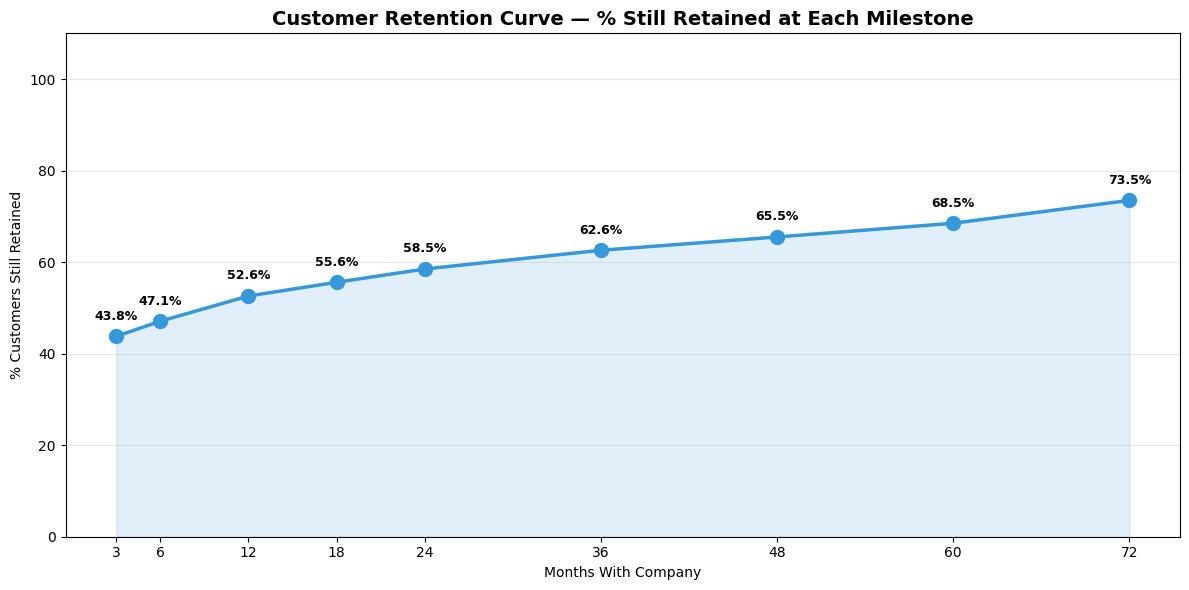

✅ Saved to docs/q14_retention_curve.png


In [52]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(q14['months_with_company'], q14['pct_retained_at_milestone'],
        marker='o', linewidth=2.5, color='#3498db', markersize=10)
ax.fill_between(q14['months_with_company'],
                q14['pct_retained_at_milestone'], alpha=0.15, color='#3498db')
for _, row in q14.iterrows():
    ax.annotate(f"{row['pct_retained_at_milestone']}%",
                xy=(row['months_with_company'], row['pct_retained_at_milestone']),
                xytext=(0, 12), textcoords='offset points', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Customer Retention Curve — % Still Retained at Each Milestone', fontsize=14, fontweight='bold')
ax.set_xlabel('Months With Company')
ax.set_ylabel('% Customers Still Retained')
ax.set_ylim(0, 110)
ax.set_xticks(q14['months_with_company'])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../docs/q14_retention_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to docs/q14_retention_curve.png")


### 📌 Business Insight — Q14

> ⚠️ **Methodology note:** This is a **cross-sectional snapshot, not a cohort study.**
> The formula `(cumulative_customers − cumulative_churned) / cumulative_customers`
> measures what fraction of all customers seen up to month T haven't churned yet —
> NOT the survival rate of a single starting cohort. This is why the curve
> starts at ~44% at month 3 rather than 100% at month 0. Treat these as
> approximate survival estimates, not true cohort retention rates.

At 3 months: **43.8%** retained (of customers seen so far)

At 6 months: **47.1%** retained

At 12 months: **52.6%** retained ← massive churn in Year 1

At 24 months: **58.5%** retained ← curve begins flattening

At 36 months: **62.6%** retained

At 60 months: **68.5%** retained ← very stable

At 72 months: **73.5%** retained

The 52.6% at month 12 is consistent with Q5's finding that **47.4% of
0–12 month customers churn** (100% − 47.4% = 52.6%) — the two queries
confirm each other.

**INTERPRETATION:**
The steepest churn period is months 0–12. After month 24, the curve
flattens significantly — customers who survive 2 years have much higher
staying power (service embeddedness, contract stability, habit formation).

The "leaky bucket" metaphor: We fill the bucket with new customers,
but ~47% leak out within the first 12 months.

**KEY METRIC FOR THE BUSINESS:**
If we improve 12-month retention by 5 percentage points (52.6% → 57.6%):
- At month 12, we have 2,186 cumulative customers
- 5% of 2,186 = ~109 additional customers retained
- At avg `$65`/month × 12 = **`~$85,000`** additional annual revenue

## Query 15 — Full Revenue Risk Matrix
**Business Question:** Where should retention budget be allocated?
Which segment × lifecycle combinations are CRITICAL vs. LOW RISK?
**SQL Concepts:** CTE + multiple CASE WHEN columns + custom ORDER BY
**Audience:** VP of Customer Success — this drives budget decisions


In [29]:
q15 = run_query("""
    WITH segment_metrics AS (
        SELECT
            tenure_band,
            Contract,
            COUNT(*) AS total_customers,
            SUM(churn_binary) AS churned_count,
            ROUND(SUM(churn_binary) * 100.0 / COUNT(*), 1) AS churn_rate_pct,
            ROUND(SUM(CASE WHEN Churn='No' THEN MonthlyCharges ELSE 0 END), 2)
                AS retained_monthly_revenue,
            ROUND(SUM(CASE WHEN Churn='Yes' THEN MonthlyCharges ELSE 0 END), 2)
                AS lost_monthly_revenue
        FROM customers
        GROUP BY tenure_band, Contract
    )
    SELECT
        tenure_band,
        Contract,
        total_customers,
        churned_count,
        churn_rate_pct,
        retained_monthly_revenue AS current_mrr_retained,
        lost_monthly_revenue AS mrr_already_lost,
        ROUND(lost_monthly_revenue * 12, 2) AS annual_revenue_lost,
        CASE
            WHEN churn_rate_pct >= 40 THEN 'CRITICAL'
            WHEN churn_rate_pct >= 20 THEN 'HIGH RISK'
            WHEN churn_rate_pct >= 10 THEN 'MODERATE'
            ELSE 'LOW RISK'
        END AS risk_level
    FROM segment_metrics
    ORDER BY
        CASE tenure_band
            WHEN '0-12 months'  THEN 1
            WHEN '13-24 months' THEN 2
            WHEN '25-36 months' THEN 3
            WHEN '37-48 months' THEN 4
            WHEN '49-60 months' THEN 5
            WHEN '61-72 months' THEN 6
        END,
        churn_rate_pct DESC
""", "Q15: Full Revenue Risk Matrix — Lifecycle × Contract")
q15



📊 Q15: Full Revenue Risk Matrix — Lifecycle × Contract


,tenure_band,Contract,total_customers,churned_count,churn_rate_pct,current_mrr_retained,mrr_already_lost,annual_revenue_lost,risk_level
0,0-12 months,Month-to-month,1994,1024,51.40,"47,785.05","68,301.45","819,617.40",CRITICAL
1,0-12 months,One year,124,13,10.50,"3,786.10",652.80,"7,833.60",MODERATE
2,0-12 months,Two year,68,0,0.00,"2,104.35",0.00,0.00,LOW RISK
3,13-24 months,Month-to-month,737,278,37.70,"29,100.85","21,980.30","263,763.60",HIGH RISK
4,13-24 months,One year,197,16,8.10,"7,739.75","1,101.35","13,216.20",LOW RISK
5,13-24 months,Two year,90,0,0.00,"2,907.60",0.00,0.00,LOW RISK
6,25-36 months,Month-to-month,486,158,32.50,"22,705.60","13,416.95","161,003.40",HIGH RISK
7,25-36 months,One year,250,20,8.00,"12,822.95","1,701.75","20,421.00",LOW RISK
8,25-36 months,Two year,96,2,2.10,"3,862.30",49.25,591.00,LOW RISK
9,37-48 months,Month-to-month,316,106,33.50,"15,641.45","9,140.05","109,680.60",HIGH RISK


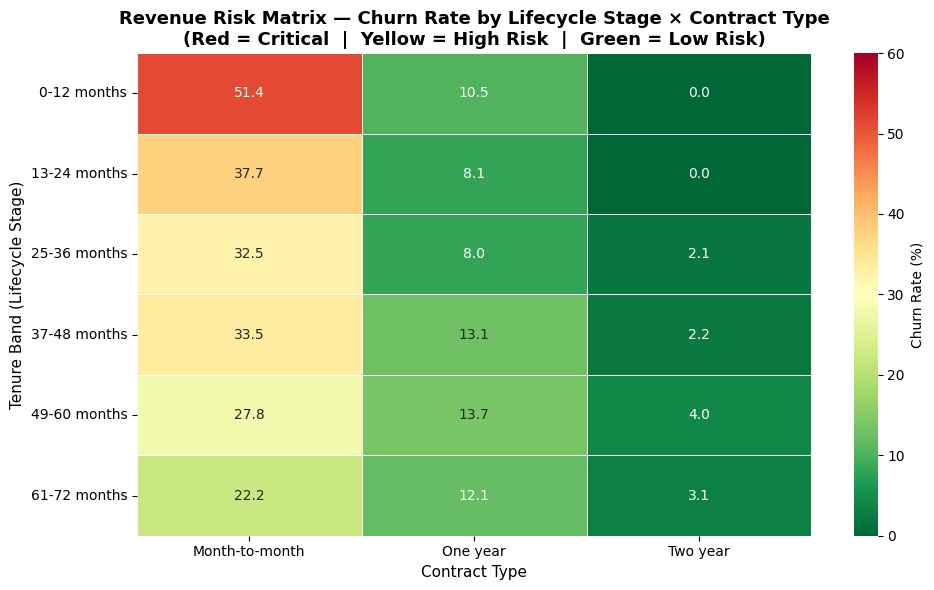

✅ Chart saved to docs/q15_risk_matrix_heatmap.png


In [55]:
# Pivot for heatmap — tenure_band rows × Contract columns
heatmap_data = q15.pivot_table(
    index='tenure_band', columns='Contract',
    values='churn_rate_pct', aggfunc='first'
)
row_order = ['0-12 months','13-24 months','25-36 months',
             '37-48 months','49-60 months','61-72 months']
heatmap_data = heatmap_data.reindex(
    [r for r in row_order if r in heatmap_data.index]
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Churn Rate (%)'},
    vmin=0, vmax=60,
    ax=ax
)
ax.set_title('Revenue Risk Matrix — Churn Rate by Lifecycle Stage × Contract Type\n'
             '(Red = Critical  |  Yellow = High Risk  |  Green = Low Risk)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Contract Type', fontsize=11)
ax.set_ylabel('Tenure Band (Lifecycle Stage)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../docs/q15_risk_matrix_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to docs/q15_risk_matrix_heatmap.png")

### 📌 Business Insight — Q15 — Revenue Risk Matrix

CRITICAL SEGMENTS (≥40% churn):
• 0-12 months + Month-to-month: 51.4% churn rate
  → 1,994 customers, `$819,617` annual revenue already lost

HIGH RISK SEGMENTS (20-40% churn):
• 13-24 months + M2M: 37.7% → `$263,764`/year
• 37-48 months + M2M: 33.5% → `$109,681`/year
• 25-36 months + M2M: 32.5% → `$161,003`/year
• 49-60 months + M2M: 27.8% → `$68,213`/year
• 61-72 months + M2M: 22.2% → `$27,887`/year

Two-year contract across ALL tenure bands: 0-3.1% churn — negligible loss.

TOTAL REVENUE AT RISK (CRITICAL + HIGH RISK) = ~$1.45M/year

BUDGET JUSTIFICATION:
If a retention program costs $50/customer to run and covers the 1,994 CRITICAL
customers: Total cost = `$99,700`. Even 15% recovery rate =
1994 × 15% × avg `$66/month` × 12 = `$237,416` protected revenue.
ROI = `$237,416 / $99,700` = 2.4× return.

PRIORITY ACTION BY RISK LEVEL:
- CRITICAL: Immediate personal CS outreach — Day 30 call mandatory
  Target: 0-12 month M2M customers (all 1,994 of them)
- HIGH RISK: Automated email sequence + annual contract incentive
- MODERATE: Monthly monitoring + 6-month check-in
- LOW RISK (Two-year contracts): Standard relationship management only


## 📋 Executive Summary — Top 5 Findings & Recommended Actions

| # | Finding | Key Metric | Recommended Action | Est. Value Protected |
|---|---------|-----------|-------------------|----------------------|
| 1 | M2M customers churn at 15× two-year rate | 42.7% vs 2.8% | Time-limited incentive: 10–15% discount to convert M2M → annual | ~`$145K` (10% conversion) |
| 2 | New Fiber + M2M is near-certain churn | 72.9% churn (Q12 #1 profile) | Day-1 CS call + Day-14 security trial + Month-2 annual offer | ~`$169K` (72.9% → 50%) |
| 3 | Seniors without TechSupport churn at 50.6% | 31pp drop with support | Free 60-day TechSupport trial for all senior signups | ~`$122K/year` |
| 4 | Electronic check payers churn at 2.8× auto-pay | 45.3% vs ~16% | $2–3/month auto-pay discount at signup | `~$654K/year` |
| 5 | 1,008 high-risk retained customers = `$588K` at risk | Q6 forward-looking | Security trial + annual offer (`$30/customer` outreach) | ~`$265K` (ROI: 8.8×) |

**Total addressable annual revenue protection across all 5 actions: ~`$1.35M`**

> All figures derived from IBM Telco Churn dataset (7,043 customers).
> Revenue projections assume historical churn rates hold and actions produce
> conservative improvement estimates. Actual results require A/B testing.

In [31]:
print("SQL ANALYSIS COMPLETE — 15 Business Queries")
print("-" * 45)
print("Key metrics from this analysis:")
print("  Overall churn rate:        26.5%")
print("  Month-to-month churn:      42.7%")
print("  Two-year churn:             2.8%")
print("  Fiber optic churn:         41.9%")
print("  6+ services churn:         ~16%")
print("  Electronic check churn:    45.3%")
print("  % retained at 12 months:   52.6%")
print("  % retained at 24 months:   58.5%")
print()
print("Top 3 Churn Personas (from Q12):")
print("  #1: M2M + Fiber optic + No Security + 0-12 months → 72.9% churn")
print("  #2: M2M + Fiber optic + Security + 0-12 months → 56.6% churn")
print("  #3: M2M + Fiber optic + No Security + 13-24 months → 53.2% churn")


SQL ANALYSIS COMPLETE — 15 Business Queries
---------------------------------------------
Key metrics from this analysis:
  Overall churn rate:        26.5%
  Month-to-month churn:      42.7%
  Two-year churn:             2.8%
  Fiber optic churn:         41.9%
  6+ services churn:         ~16%
  Electronic check churn:    45.3%
  % retained at 12 months:   52.6%
  % retained at 24 months:   58.5%

Top 3 Churn Personas (from Q12):
  #1: M2M + Fiber optic + No Security + 0-12 months → 72.9% churn
  #2: M2M + Fiber optic + Security + 0-12 months → 56.6% churn
  #3: M2M + Fiber optic + No Security + 13-24 months → 53.2% churn


In [32]:
conn.close()